# 03 - Background Removal and Neuron-Enhanced Movie QC

This notebook evaluates the background-rejection model output by comparing the preprocessed movie to the neuron-enhanced movie saved in ``paths.rmbg_zarr_path``. QC focuses on residual structure, temporal variance, and whether neural signals are preserved without introducing structured artifacts.

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path

# Locate the repository root from the current notebook working directory.
def find_repo_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "Airscope_ca").is_dir() and (path / "configs").is_dir():
            return path
    raise RuntimeError(f"Could not find repo root from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))

DATA_PATH = "/mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames"
OUT_PATH = DATA_PATH.replace("frames", "Analysis")
print(f"REPO_ROOT : {REPO_ROOT}")
print(f"DATA_PATH : {DATA_PATH}")
print(f"OUT_PATH  : {OUT_PATH}")


REPO_ROOT : /data/home/angran/BBNC/code/PICO_ca_processing_release
DATA_PATH : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames
OUT_PATH  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis


In [2]:
# Compose a reproducible Hydra config for this notebook run.
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            f"data_path={DATA_PATH}",
            f"out_path={OUT_PATH}",
            "motion=suite2p",
            "rmbg=ddp",
            "rmbg.rmbg_chunk_size=500",
            f"rmbg.ckpt_pth={REPO_ROOT / 'ckpt' / 'background_rejection_ckpt_resize_2.pth'}",
        ],
    )

print(OmegaConf.to_yaml(cfg))


motion:
  fr: 10
  mc_chunk_size: 1000
  zarr_chunk_size: 1000
  method: suite2p
  device: cuda
  suite2p:
    align_by_chan2: false
    nimg_init: 400
    maxregshift: 0.1
    do_bidiphase: false
    bidiphase: 0.0
    batch_size: 100
    nonrigid: true
    maxregshiftNR: 5
    block_size:
    - 128
    - 128
    smooth_sigma_time: 0
    smooth_sigma: 1.15
    spatial_taper: 3.45
    th_badframes: 1.0
    norm_frames: true
    snr_thresh: 1.2
    subpixel: 10
    two_step_registration: false
    reg_tif: false
    reg_tif_chan2: false
preprocessing:
  crop_parameter:
  - 153
  - 303
  - 1000
  - 1000
  intensity_corr_flag: false
  bad_frame_detect_flag: false
  preprocess_workers: 64
  preprocess_chunk_size: 512
  zarr_chunk_size: 500
rmbg:
  up_sample: 2
  rmbg_chunk_size: 500
  zarr_chunk_size: 500
  rmbg_gsize: 6
  batch_size: 8
  print_interval: 20
  use_amp: true
  copy_interval: 4
  num_process_per_gpu: 2
  ckpt_pth: /data/home/angran/BBNC/code/PICO_ca_processing_release/ckpt/ba

In [3]:
# Imports used by this notebook only.
import importlib
import os
import logging

from Airscope_ca.process_script import build_paths, setup_logger
import Airscope_ca.pipeline as pipeline
import Airscope_ca.pipeline.background_removal as background_removal_module
from Airscope_ca.utils.io_videos import open_zarr_array
from airscope_notebook_tools import (
    set_publication_style,
    sample_indices,
    plot_frame_montage,
    plot_projection_panel,
    plot_before_after_frames,
    plot_background_removal_qc,
    list_stage_outputs,
)

# Reload renamed pipeline modules so spawned RMBG workers use the current
# Airscope_ca.pipeline.background_removal module, not a stale stage_rmbg object.
importlib.reload(background_removal_module)
pipeline = importlib.reload(pipeline)
get_frame_count = pipeline.get_frame_count
remove_background = pipeline.remove_background

set_publication_style()
os.makedirs(OUT_PATH, exist_ok=True)
paths = build_paths(cfg)
logger = setup_logger(OUT_PATH)
logger.addHandler(logging.StreamHandler())

frame_count = get_frame_count(cfg)
print(f"Frame count: {frame_count}")
print(f"MC zarr    : {paths.mc_zarr_path}")
print(f"Pre zarr   : {paths.preprocess_zarr_path}")
print(f"RMBG zarr  : {paths.rmbg_zarr_path}")
print(f"Seg out    : {paths.seg_out}")


/data/home/angran/anaconda3/envs/PICO/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/home/angran/BBNC/code/PICO_ca_processing_release/Airscope_ca/caiman/source_extraction/cnmf/params.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
       25212 [process_script.py:        setup_logger():87] [3060046] Logging INFO and above from root logger to /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/log_file.log


4000
Frame count: 4000
MC zarr    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/motion_corrected.zarr
Pre zarr   : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr
RMBG zarr  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr
Seg out    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1


## 1. Inspect Background-Removal Configuration

In [4]:
# Confirm inference configuration before launching GPU background rejection.
print(f"gpu_ids             : {cfg.rmbg.gpu_ids}")
print(f"multi_gpu           : {cfg.rmbg.multi_gpu}")
print(f"num_process_per_gpu : {cfg.rmbg.num_process_per_gpu}")
print(f"batch_size          : {cfg.rmbg.batch_size}")
print(f"chunk_size          : {cfg.rmbg.rmbg_chunk_size}")
print(f"checkpoint          : {cfg.rmbg.ckpt_pth}")

gpu_ids             : 0,1,2,3
multi_gpu           : True
num_process_per_gpu : 2
batch_size          : 8
chunk_size          : 500
checkpoint          : /data/home/angran/BBNC/code/PICO_ca_processing_release/ckpt/background_rejection_ckpt_resize_2.pth


## 2. Preprocessed Input QC

In [5]:
# Load the preprocessed movie written by notebook 02.
pre_arr = open_zarr_array(paths.preprocess_zarr_path, mode="r")

## 3. Run Background Removal

In [6]:
# Run the learned background-removal model on the preprocessed movie.
# Input: paths.preprocessed_zarr_path; output: paths.rmbg_zarr_path.
remove_background(cfg, paths, logger)
print(f"Background removal complete: {paths.rmbg_zarr_path}")

=======>background subtraction<=======

       35700 [background_removal.py:   remove_background():50] [3060046] =======>background subtraction<=======

mp.spawn RMBG: 4 GPU(s) ['0', '1', '2', '3'], 2 process(es)/GPU, 8 worker(s), 8 chunks
       36021 [background_removal.py:_remove_background_multi_gpu():254] [3060046] mp.spawn RMBG: 4 GPU(s) ['0', '1', '2', '3'], 2 process(es)/GPU, 8 worker(s), 8 chunks
/data/home/angran/BBNC/code/PICO_ca_processing_release/Airscope_ca/caiman/source_extraction/cnmf/params.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/data/home/angran/BBNC/code/PICO_ca_processing_release/Airscope_ca/caiman/source_extraction/cnmf/params.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources

[worker 7 -> GPU 3 / cuda:3] RMBG chunk 7 [3500:4000]
[worker 1 -> GPU 1 / cuda:1] RMBG chunk 1 [500:1000]
[worker 5 -> GPU 1 / cuda:1] RMBG chunk 5 [2500:3000]
[worker 2 -> GPU 2 / cuda:2] RMBG chunk 2 [1000:1500]
[worker 0 -> GPU 0 / cuda:0] RMBG chunk 0 [0:500]
[worker 3 -> GPU 3 / cuda:3] RMBG chunk 3 [1500:2000]
[worker 6 -> GPU 2 / cuda:2] RMBG chunk 6 [3000:3500]
[worker 4 -> GPU 0 / cuda:0] RMBG chunk 4 [2000:2500]
[rank 7] [Inference Video] [Patches: 1/276] [ETA: 1:34:28]
[rank 1] [Inference Video] [Patches: 1/276] [ETA: 1:35:30]
[rank 5] [Inference Video] [Patches: 1/276] [ETA: 1:35:36]
[rank 2] [Inference Video] [Patches: 1/276] [ETA: 1:33:02]
[rank 0] [Inference Video] [Patches: 1/276] [ETA: 1:35:21]
[rank 7] [Inference Video] [Patches: 20/276] [ETA: 0:05:02]
[rank 3] [Inference Video] [Patches: 1/276] [ETA: 1:38:31]
[rank 6] [Inference Video] [Patches: 1/276] [ETA: 1:38:16]
[rank 4] [Inference Video] [Patches: 1/276] [ETA: 1:37:58]
[rank 2] [Inference Video] [Patches: 20/2

=======>RMBG Zarr saved: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr<=======

      272946 [background_removal.py:   remove_background():86] [3060046] =======>RMBG Zarr saved: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr<=======



Background removal complete: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr


## 4. Neuron-Enhanced Movie QC

In [7]:
# Reopen the neuron-enhanced movie for QC from the persisted output.
rmbg_arr = open_zarr_array(paths.rmbg_zarr_path, mode="r")

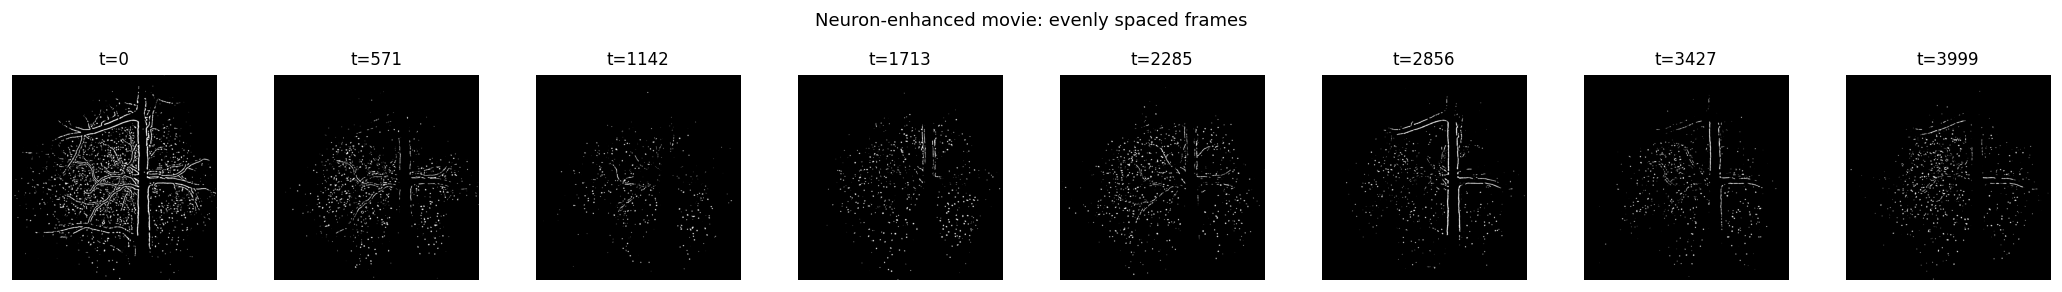

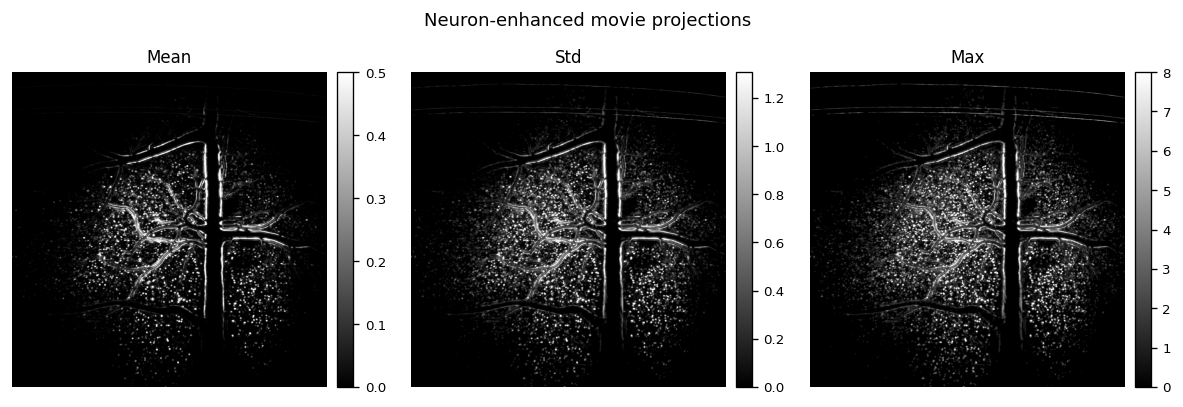

In [8]:
_ = plot_frame_montage(rmbg_arr, n=8, title="Neuron-enhanced movie: evenly spaced frames")
_ = plot_projection_panel(rmbg_arr, title="Neuron-enhanced movie projections", n_samples=128)

## 5. Preprocessed vs Neuron-Enhanced Residuals

Output directory: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg


[]

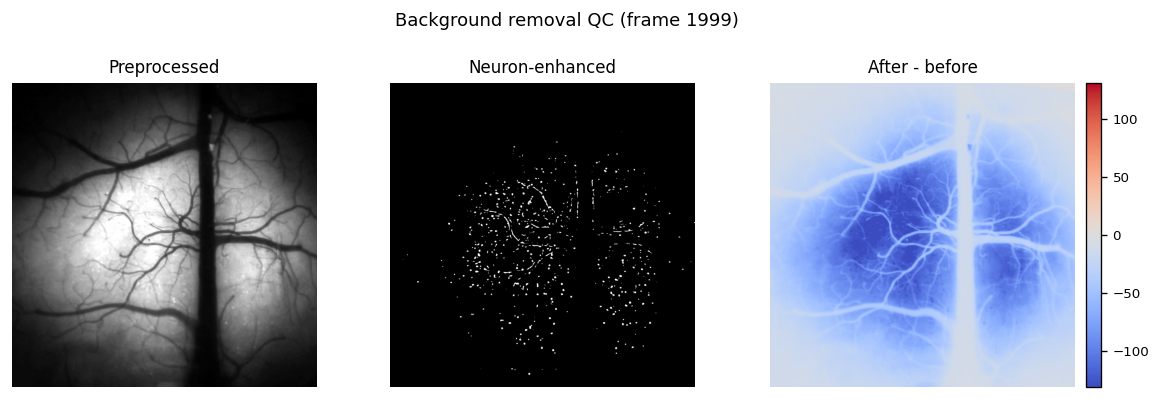

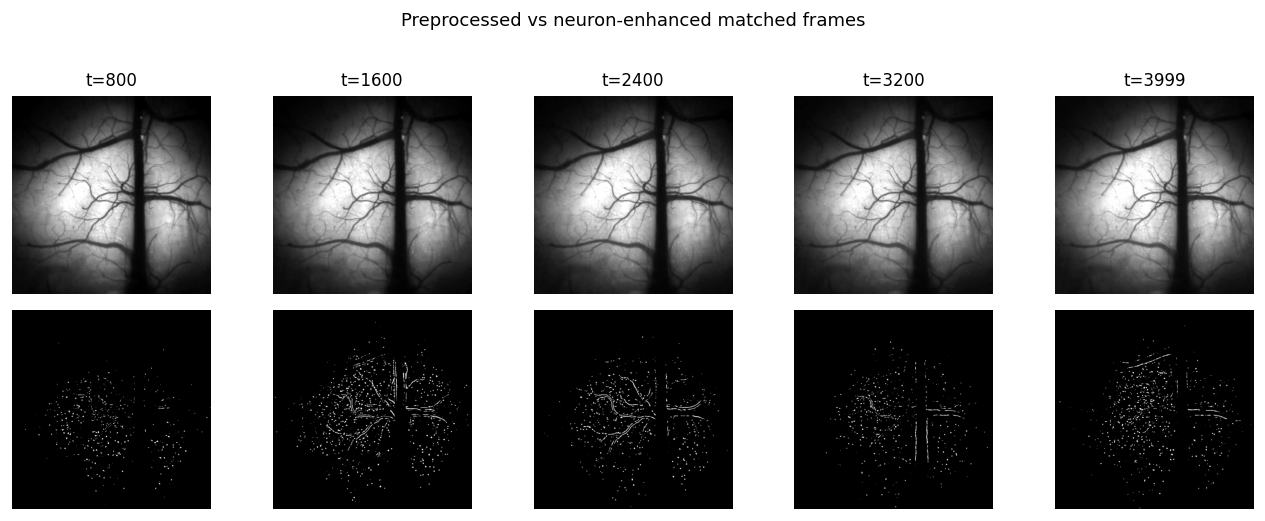

In [9]:
# Compare input and output frames to inspect residual background and signal preservation.
compare_index = int(sample_indices(min(pre_arr.shape[0], rmbg_arr.shape[0]), n=3)[1])
_ = plot_background_removal_qc(pre_arr, rmbg_arr, index=compare_index)
_ = plot_before_after_frames(pre_arr, rmbg_arr, indices=[800, 1600, 2400, 3200, 3999], n=5, title="Preprocessed vs neuron-enhanced matched frames")
list_stage_outputs(paths.rmbg_out, patterns=("*.png", "*.avi", "*.zarr"), max_items=40)